# Imports

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from catboost import CatBoostClassifier

import pickle
import shap

# Сalculating SHAP values

In [3]:
df_test = pd.read_csv('../data/processed/cut_corr_imp_test.csv')
df_test.shape

(600000, 61)

In [5]:
X_test = df_test.drop(['id', 'flag'], axis=1)
y_test = df_test.flag
X_test.shape, y_test.shape

((600000, 59), (600000,))

In [6]:
# Загружаем список весов моделей ансамбля
with open('../models/сonservative_models_weights.pkl', 'rb') as f:
    state = pickle.load(f)
    
val_auc_list = state['val_auc_list']
val_auc_list

[0.7576036850511159,
 0.7554545982995526,
 0.7532810994057619,
 0.7546988571803108,
 0.7524269260453276,
 0.7546930331964138]

In [7]:
# Соберём словарь с моделями и их весами
models_dict = {}
for i in range(5):
    model = CatBoostClassifier()
    model.load_model(f'../models/fold_{i}_сonservative_model.bin')
    models_dict[f'fold_{i}_model'] = (model, val_auc_list[i])

model = CatBoostClassifier()
model.load_model('../models/full_data_сonservative_model.bin')
models_dict['full_data_model'] = (model, val_auc_list[5])
models_dict

{'fold_0_model': (<catboost.core.CatBoostClassifier at 0x143b97f50>,
  0.7576036850511159),
 'fold_1_model': (<catboost.core.CatBoostClassifier at 0x143b97fe0>,
  0.7554545982995526),
 'fold_2_model': (<catboost.core.CatBoostClassifier at 0x143b96990>,
  0.7532810994057619),
 'fold_3_model': (<catboost.core.CatBoostClassifier at 0x103a208c0>,
  0.7546988571803108),
 'fold_4_model': (<catboost.core.CatBoostClassifier at 0x143631f70>,
  0.7524269260453276),
 'full_data_model': (<catboost.core.CatBoostClassifier at 0x143619760>,
  0.7546930331964138)}

In [8]:
# Создадим словарь для SHAP-значений и весов моделей ансамбля
shap_dict = {}

# Для каждой модели ансамбля
for model_name, (model, weight) in models_dict.items():
    
    # Создаём объект толкователя SHAP
    explainer = shap.TreeExplainer(model)

    """
    Вычисляем SHAP-значения на тестовой выборке X_test
    Получаем — массив размером (n_samples, n_features), где
    строки соответствуют строкам X_test,
    а  столбцы это вклад соответствующего признака в прогноз модели.
    """
    shap_values = explainer.shap_values(X_test)

    # Сохраняем SHAP-значения и вес модели в словарь 
    shap_dict[model_name] = (shap_values, weight)

In [9]:
shap_dict['fold_0_model'][0].shape

(600000, 59)

In [10]:
"""
Для dвычисления средневзвешенных по весам моделей SHAP-значений создаём 
массив из нулей размером X_test (SHAP-значение одной модели)
""" 
avg_shap = np.zeros_like(X_test)

# Считаем сумму весов всех моделей в ансамбле для нормирования SHAP-значений
weights_sum = sum(val_auc_list)

# Суммируем в массиве взвешенные SHAP-значения каждой модели
for shap_vals, weight in shap_dict.values():
    avg_shap += shap_vals * weight
    
# Делим  сумму SHAP-значения на сумму весов моделей
avg_shap /= weights_sum

# Summary plot

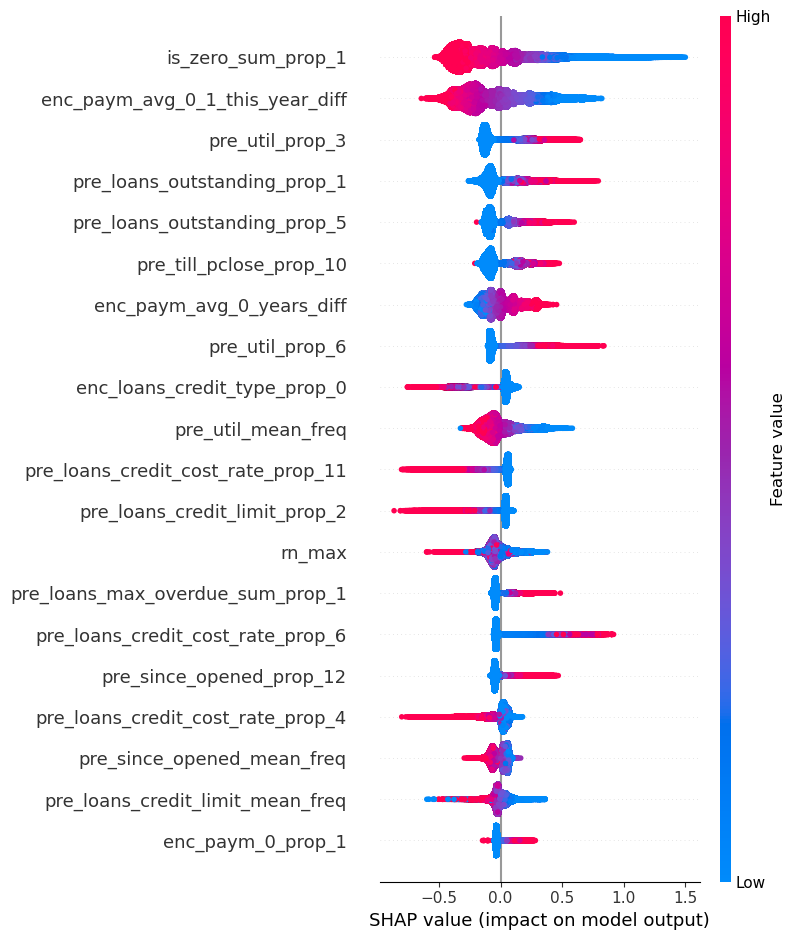

In [11]:
# Строим обобщённый график важности 20ти самых важных признаков
shap.summary_plot(avg_shap, X_test)

Интерпретация графика.  
Рассмотрим первые пять признаков дающих наибольший вклад в предсказательную способность ансамбля.  

1. is_zero_sum_prop_1 - это признак суммы флагов отсутствия просрочек в среднем на один кредит клиента по всем периодам от 5 до 90 дней,
   то есть он отражает регулярность платежей клиента.  
   Вносит самый высокий вклад в качество ансамбля.  
   Высокие значения признака (красные точки, много едениц) отражают редкие просрочки и ожидаемо  уводят SHAP value влево(понижает), то есть     снижают вероятность события класса 1 - дефолта.
   Соответственно низкие значения признака повышают вероятность дефолта.
   Вывод: Клиенты с большим количеством "чистых" периодов имеют существенно меньший риск — это основной “фильтр надёжности”.

2. enc_paym_avg_0_1_this_year_diff - признак разницы между средними значениями статусов платежей 0 и 1 на один кредит клиента за последний      год. Высокие значения признака отражают большую разницу между этими статусами и уводят SHAP value влево, то есть снижают                     вероятность дефолта клиента.
   Вывод: Можно предположить что 0 это некий положительный статус (платёж закрыт вовремя), а 1 - негативный статус (просрочка).                 Статус 0 встречается в датасете в разы чаще чем статус 1 что характерно для большинства клиентов.
   
3. pre_util_prop_3 - среднее на один кредит клиента одного из интервалов отношения оставшейся невыплаченной суммы кредита к кредитному          лимиту.
   Высокиие значения признака уводят SHAP value вправо(дефолт), низкие влево.
   Можно сделать вывод что это интервал высоких отношений, то есть невыплаченная сумма кредита близка к кредитному лимиту и частое наличие      такого значения признака в кредитах клиента говорит о его закредитованности и высоком риске дефолта.

4. pre_loans_outstanding_prop_1 - признак среднего присутствия на один кредит клиента некоего интервала невыплаченной суммы кредита.
   Высокиие значения признака уводят SHAP value вправо(дефолт), низкие влево.
   Так же как и для предыдушего признака можно сделать вывод что это интервал высоких значений невыплаченных сумм, и частое наличие             такого значения признака в кредитах клиента говорит о его закредитованности и высоком риске дефолта.

5. pre_loans_outstanding_prop_5 - аналогичный предыдушему признак, но отражающий частоту появления другого интервала значений невыплаченных     сумм, очевидно также высоких. Признак повторяет те же паттерны что и предыдущий.

Все пять признаков имеют отчётливо выраженное значение: они либо уменьшают, либо увеличивают вероятность наступления дефолта по мере увеличения своих значений.

Для всех признаков характерно, что экстремальные значения дают сильное смещение прогноза модели. Однако в признаке pre_loans_outstanding_prop_5 присутствует аномалия в виде еденичной красной точки слева (один или несколько клиентов) это, вероятно, объясняется влиянием остальных признаков на поведение моделей ансамбля, в контексте значений остальных признаков в этом или в этих случаях высокие значения признака pre_loans_outstanding_prop_5 наоборот понижали SHAP value понижая вероятность дефолта клиента.  
Подобные единичные аномалии могут встречаться у сложных моделей, и если проверить значения остальных топ-признаков у таких клиентов, скорее всего обнаружатся экстремально позитивные характеристики. Такие случаи можно анализировать отдельно чтобы проверить нет ли в данных каких-то специфических смешанных паттернов или ошибочной интерпретации отдельного признакаи и даже создать отдельную подвыборку для обучения новой модели и их дополнительной оценки.

# Bar plot

Для подтверждения важности признаков отраженнных в summary plot построим bar plot средней абсолютной важности SHAP значений признаков.

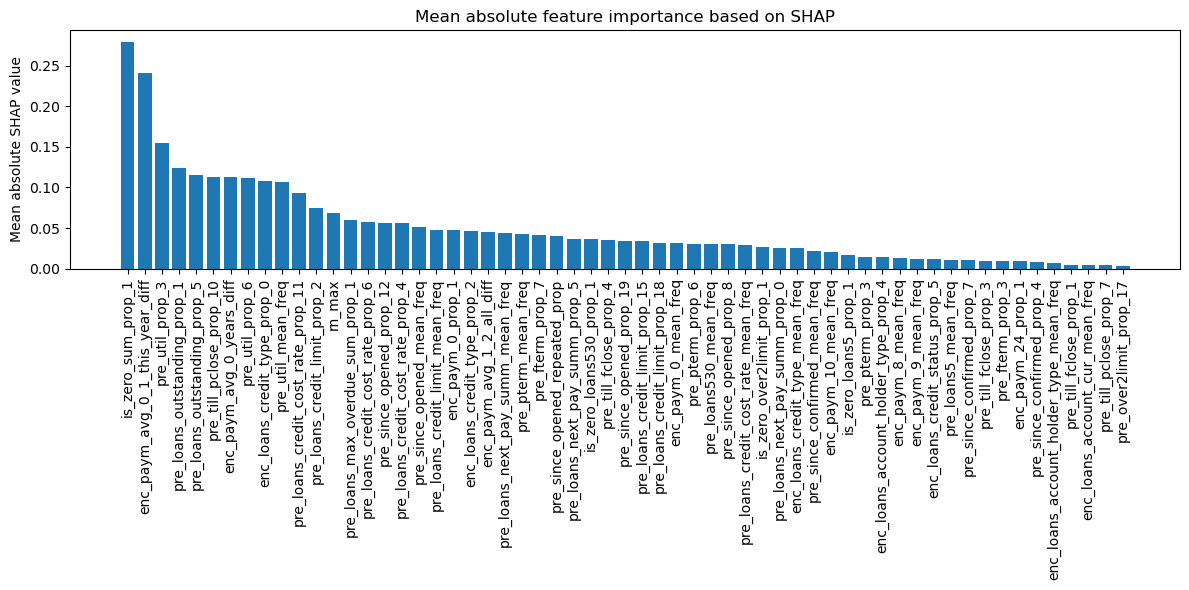

In [12]:
"""
Вычислим среднее абсолютное SHAP значение для каждого признака по всем объектам.
Будем брать модуль SHAP value, что бы учесть положительное и отрицательное влияние на 
вероятность предсказания первого класса.
"""
mean_abs_shap = np.mean(np.abs(avg_shap), axis=0)

"""
Получим индексы которые отсортировали бы массив по возрастанию (argsort)
и инвертируем сорттировку слайсингом.
"""
sorted_idx = np.argsort(mean_abs_shap)[::-1]

# Получим отсортированные названия признаков для подписей на графике
sorted_features = X_test.columns[sorted_idx]

# Получаем отсортированные значения средней абсолютной важности
sorted_mean_abs_shap = mean_abs_shap[sorted_idx]

plt.figure(figsize=(12, 6))
plt.bar(sorted_features, sorted_mean_abs_shap)

# Поворачиваем имена признаков для лучшей читаемости
plt.xticks(rotation=90)
plt.ylabel('Mean absolute SHAP value')
plt.title('Mean absolute feature importance based on SHAP')
plt.tight_layout()
plt.show()

Порядок признаков в bar plot совпадает с порядком на summary plot: лидеры по важности остаются теми же. 

Построим график средних важностей признаков моделей для сравнения со среднимиабсолютными SHAP значениями.

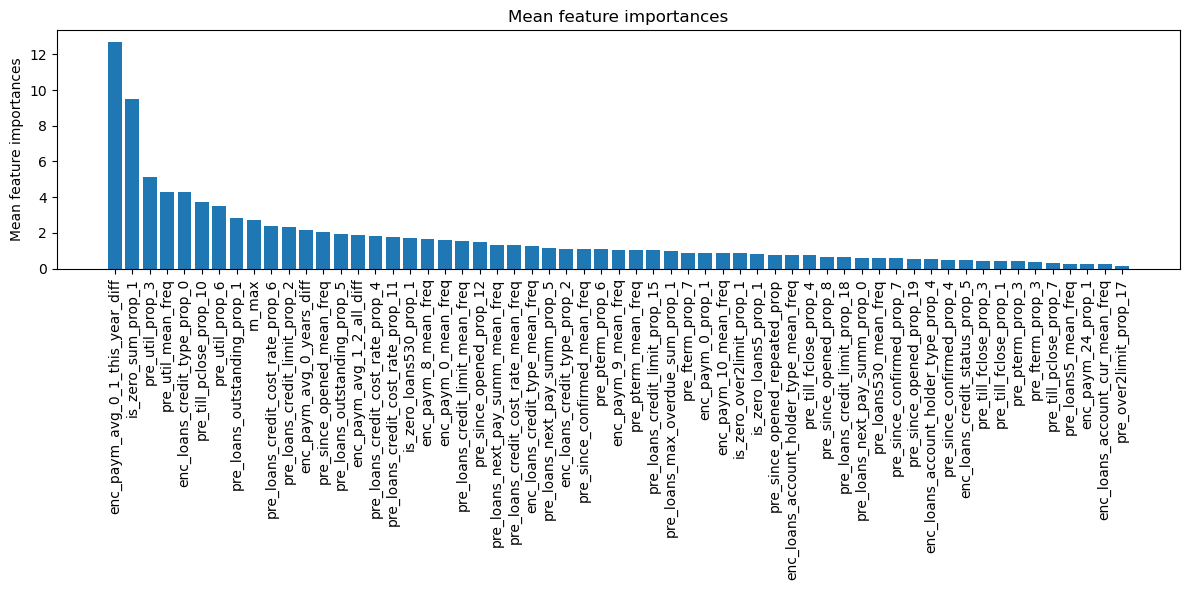

In [13]:
# Создадим словарь для накопления важностей признаков моделей ансамбля
importances_dict = {col: [] for col in X_test.columns}

# Для каждой модели из ансамбля получаем важности признаков и записываем их в словарь
for value in models_dict.values():
    importances = value[0].get_feature_importance()
    for col, imp in zip(X_test.columns, importances):
            importances_dict[col].append(imp)

# Рассчитываем среднее значение важности для каждого признака
mean_importances_dict = {col: np.mean(imps) for col, imps in importances_dict.items()}

# Сортируем признаки по убыванию среднего значения важности
sorted_mean_importances_dict = dict(
    sorted(mean_importances_dict.items(), key=lambda x: x[1], reverse=True)
)

# Сохраняем отсортированные признаки и соответствующие значения важности для построения графика
features = sorted_mean_importances_dict.keys()
values = sorted_mean_importances_dict.values()

# Строим столбчатую диаграмму значений важности по признакам
plt.figure(figsize=(12, 6))
plt.bar(features, values)     

# Поворачиваем подписи признаков на оси X для улучшения читаемости
plt.xticks(rotation=90)
plt.ylabel('Mean feature importances')  
plt.title('Mean feature importances')   
plt.tight_layout()                      
plt.show()                             

Первые два признака занимают лидирующие позиции в обоих рейтингах — по средним feature importances и по mean absolute SHAP values ансамбля, хотя их порядок отличается. Третье место полностью совпадает в обоих списках.  
Для остальных признаков последовательность начинает различаться.

Различия в рейтингах объясняются особенностями двух методов:  
SHAP важность отражает средний вклад признака в индивидуальные предсказания модели — насколько сильно этот признак влияет на результат для каждого отдельного случая.

Классическая feature importance показывает, как часто и полезно признак используется при разбиениях деревьев, оценивая его роль в структуре модели в целом, но не всегда отражает, как реально этот признак влияет на финальный прогноз.

Искажения в ранжировании могут возникать из-за наличия сложных взаимодействий между признаками или из-за выраженных пороговых эффектов — SHAP их лучше фиксирует. 

Устойчивость топа признаков по двум ключевым метрикам говорит о высокой информативности и надёжности архитектуры моделей.

## Dependence plot

Построим графики зависимостей SHAP value от значений признака для трёх самых важных признаков чтобы: 
- Оценить, как именно значения каждого из этих признаков влияют на вклад в итоговое решение модели — то есть понять направление, силу и        характер этого влияния.
- Обнаружить типовые или аномальные эффекты: например, есть ли уровни признака, при которых вклад резко меняется, есть ли нелинейные          закономерности и взаимодействия с другими признаками.

По оси X на графике откладываются значения признака, по оси Y SHAP value этого признака, цветом обозначаются значения дополнительного признака, который автоматически подбирается исходя из того какой признак образует с основным признаком максимальное взаимодействие, то есть который наиболее сильно влияет на SHAP value основного признака при его одинаковых значениях. Это позволяет выявить скрытые взаимодействия между признаками.

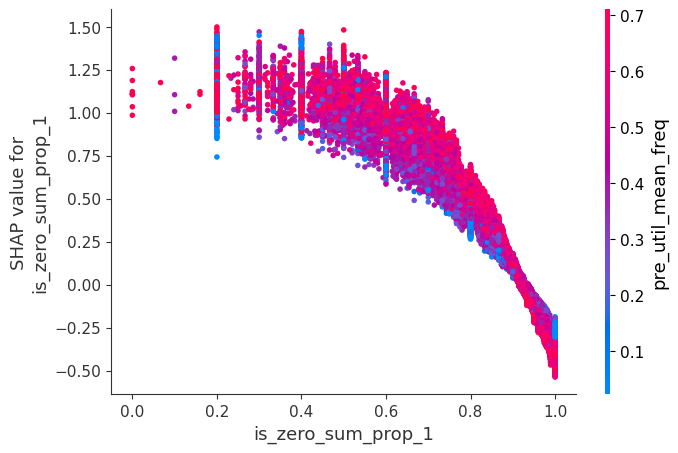

In [14]:
shap.dependence_plot('is_zero_sum_prop_1', avg_shap, X_test)

На графике можно наблюдать монотонную зависимость - при увеличении значения признака is_zero_sum_prop_1 его SHAP value стабильно снижается, переходя от положительных значений (укрепляющих прогноз дефолта) к отрицательным (исиливает принятие решения о надёжности клиента). 
Влияние признака распределено неравномерно - низкие его значения дают высокий вклад в предсказание дефолта, тогда как высокие значения признака меньше влияют на предсказание надёжности клиента.  

Области нейтрального влияния  
В интервале значений признака около 0.9 SHAP value близко к нулю. В этих точках признак практически не влияет на решение модели, а итоговое предсказание определяется за счёт других признаков. Парный признак так же не имеет влияние в этой точке что видно по отсутствию   вертикального цветового расслоения.  

Взаимодействие с дополнительным признаком  
pre_util_mean_freq - среднее на кредит клиента суммарная частотность значений признака "отношение оставшейся невыплаченной суммы кредита к кредитному лимиту в кредитах клиента", показывает насколько поведение отличается от типичного поведения остальных клиентов выборки.
На большинстве диапазонов X наблюдается вертикальная стратификация точек по цвету:
При одних и тех же значениях is_zero_sum_prop_1 объекты с большим pre_util_mean_freq (малиновые точки) имеют более высокие SHAP value чем с низким и наоборот при значениях is_zero_sum_prop_1 больше 0.9  — это указывает на выраженное статистическое взаимодействие между этими двумя признаками.

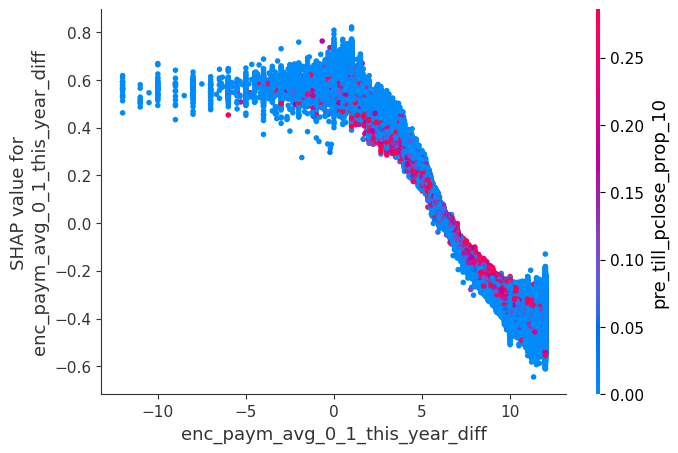

In [15]:
shap.dependence_plot('enc_paym_avg_0_1_this_year_diff', avg_shap, X_test)

Зависимость SHAP value от значения признака enc_paym_avg_0_1_this_year_diff носит нелинейный характер - при отрицательных значениях признака значения SHAP value стабильно высокие и не меняются (предсказание дефолта), а с ростом положительных значений признака SHAP value линейно убывает вплоть до отрицательных значений (надёжные клиенты).   
Это согласуется с предыдущмими выводами о характере статусов платежей 0 и 1, 0 - некий позитвный статус, 1 - негативный и их отрицательная разница говорит о высокой концентрации негативных статусов 1.  
Влияние признака интенсивно меняется в узком диапазоне около нуля, что можно расценивать как пороговое значение.  
Этот качественный скачок вероятнее всего можно объяснить тем что почти все деревья ансамбля CatBoost выбирают разбиение по этому порогу, что отражает резкую смену сценария риска между двумя классами данных. Модели здесь четко делят клиентов на надёжных и проблемных. 

В целом влияние признака на SHAP value  почти симметрично - от 0.8 до - 0.6.

Область нейтрального вклада  
В диапазоне значений признака enc_paym_avg_0_1_this_year_diff около 5 SHAP value находится близко к нулю. В этот момент признак перестает оказывать заметное влияние на предсказание модели — итог формируется за счет других переменных. Парный признак так же не имеет влияние в этой точке что видно по отсутствию   вертикального цветового расслоения.   

Взаимодействие с дополнительным признаком  
pre_till_pclose_prop_10 - доля в кредитах клиента некоего интервала признака "Плановое количество дней с даты сбора данных до даты закрытия кредита".
При отрицательных значениях основного признака не наблюдается выраженной цветовой дифференциации парного признака pre_till_pclose_prop_10. 
При положительных значениях enc_paym_avg_0_1_this_year_diff наблюдается влияние парного признака в сторону уменьшения SHAP value при высоких его значениях (малиновые точки), а после точки нейтрального вклада (около 5 по enc_paym_avg_0_1_this_year_diff) наоборот - высокие значения 
pre_till_pclose_prop_10 повышают SHAP value.
Таким образом можно сказать что статистическая зависимость между признаками существует -  SHAP value зависит не только от значения основного признака, но и от величины парного.
При больших значениях enc_paym_avg_0_1_this_year_diff (9-12) эффект взаимодействия исчезает и цветовое разделение пропадает. 

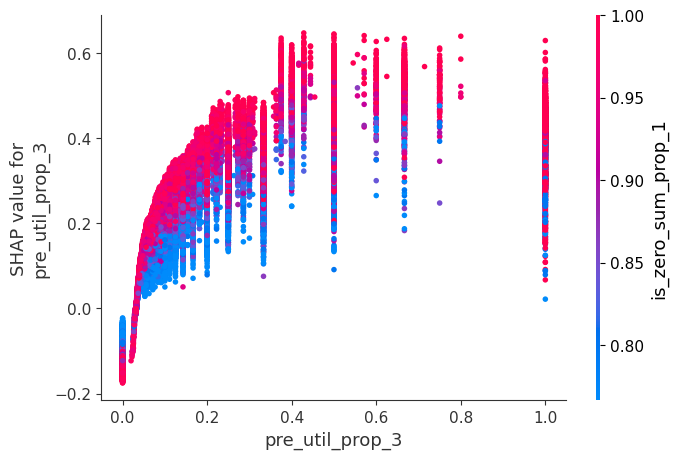

In [16]:
shap.dependence_plot('pre_util_prop_3', avg_shap, X_test)

На графике наблюдается нелинейная возрастающая зависимость SHAP value от значений основного признака pre_util_prop_3 - доля в кредитах клиента некоего инетрвала значений отношения оставшейся невыплаченной суммы кредита к кредитному лимиту . 
С ростом значений основного признака наблюдается резкое увеличение SHAP value с отрицательных значений (надёжные клиенты)  и около значений 0.1 - 0.3 выход на плато.  
На SHAP value сильно влияют значения парного признака is_zero_sum_prop_1(топовый признак) это признак суммы флагов отсутствия просрочек в среднем на один кредит клиента по всем периодам от 5 до 90 дней, то есть он отражает регулярность платежей клиента.  
Отчетливо видна стратификация по цветам почти на всех значениях основного признака, причем при значении 0 основного признака высокие значения парного признака понижают SHAP value (малиновые точки), а во всех остальных случаях повышают.   

Ранее был сделан вывод что признак  pre_util_prop_3 отражает долю в кредитах клиента неких высоких отношений невыплаченной суммы кредита к кредитному лимиту, то есть невыплаченная сумма кредита близка к кредитному лимиту и частое наличие такого значения признака в кредитах клиента говорит о его закредитованности и высоком риске дефолта.  
Теперь же судя по тому что рост значений признака после примерно 0.1 не оказывает существенного влияния на рост SHAP value можно предположить что признак не обязательно говорит о закредитованности, это например, могут быть недавно взятые кредиты.

# Waterfall plot

Для анализа поведения моделей в областях нейтрального вклада двух топовых признаков is_zero_sum_prop_1 и  enc_paym_avg_0_1_this_year_diff построим Waterfall графики для усредненных значений всех признаков объектов входящих в эти области и для самых типичных представителей этих групп, чьи значения признаков самые близкие к медианным.

In [17]:
"""
Расчётаем взвешенное SHAP base value (в логитах) для ансамбля моделей.
Base value в задачах классификации — это среднее предсказание модели 
в логитах (log-odds), до применения функции сигмоида и преобразования в вероятность.
"""
# Создаём список для base_value моделей
base_values = []

# Для всех моделей ансамбля
for model, weight in models_dict.values():    
    # создаём SHAP-объект для интерпретации модели
    explainer = shap.TreeExplainer(model)
    # Вычисляем base_value модели
    base_value_model = explainer.expected_value
    # Умножаем на вес модели и кладем в список
    base_values.append(base_value_model * weight)

# Cумма весов всех моделей(AUC на валидации)
weights_sum = sum(val[1] for val in models_dict.values())

# Финальное усреднённое base value ансамбля
ensemble_base_value = sum(base_values) / weights_sum

print("Взвешенное base value (в логитах):", ensemble_base_value)

Взвешенное base value (в логитах): [-0.02140088]


## is_zero_sum_prop_1

In [18]:
# Найдем значение признака при котором SHAP value близко к нулю
feature_name = 'is_zero_sum_prop_1'
# Найдем индекс признака
i = X_test.columns.get_loc(feature_name)
idx_group = np.where(np.abs(avg_shap[:, i]) < 0.05)[0]
idx_group.shape

(46914,)

In [19]:
# Выберем группу объектов с низким SHAP value и оценим их меры среднего
feature_values_group = X_test.iloc[idx_group][feature_name]
group_mean = feature_values_group.mean()
group_median = feature_values_group.median()
print("Среднее группы", group_mean)
print("Медиана группы", group_median)

Среднее группы 0.9253431830994949
Медиана группы 0.925


In [20]:
"""
Так как распределение SHAP value на dependence_plot скошено, 
то ориентироваться будем на медианное значение.
Выделим группу объектов находящихся в областях нейтрального
вклада признака в решение моделей ансамбля, с зазором ± 0.01
"""
threshold = 0.01
# Индексы объектов входящих в требуемый диапазон признака
idx_group = np.where(
    (X_test[feature_name] >= group_median - threshold) & (X_test[feature_name] <= group_median + threshold)
)[0]
print("Number of objects in the group", idx_group.shape[0])

Number of objects in the group 53890


In [21]:
"""
Получаем матрицу признаков для группы и 
для каждого признака вычисляем медиану.
"""
group_features = X_test.iloc[idx_group].values
median_feature_values = np.median(group_features, axis=0)
group_features.shape

(53890, 59)

In [22]:
"""
Вычисляем медианные SHAP значения для всех признаков по группе,
avg_shap – массив средневзвешенных SHAP значений 
вычисленный ранее.
"""
median_shap_group = np.median(avg_shap[idx_group], axis=0)

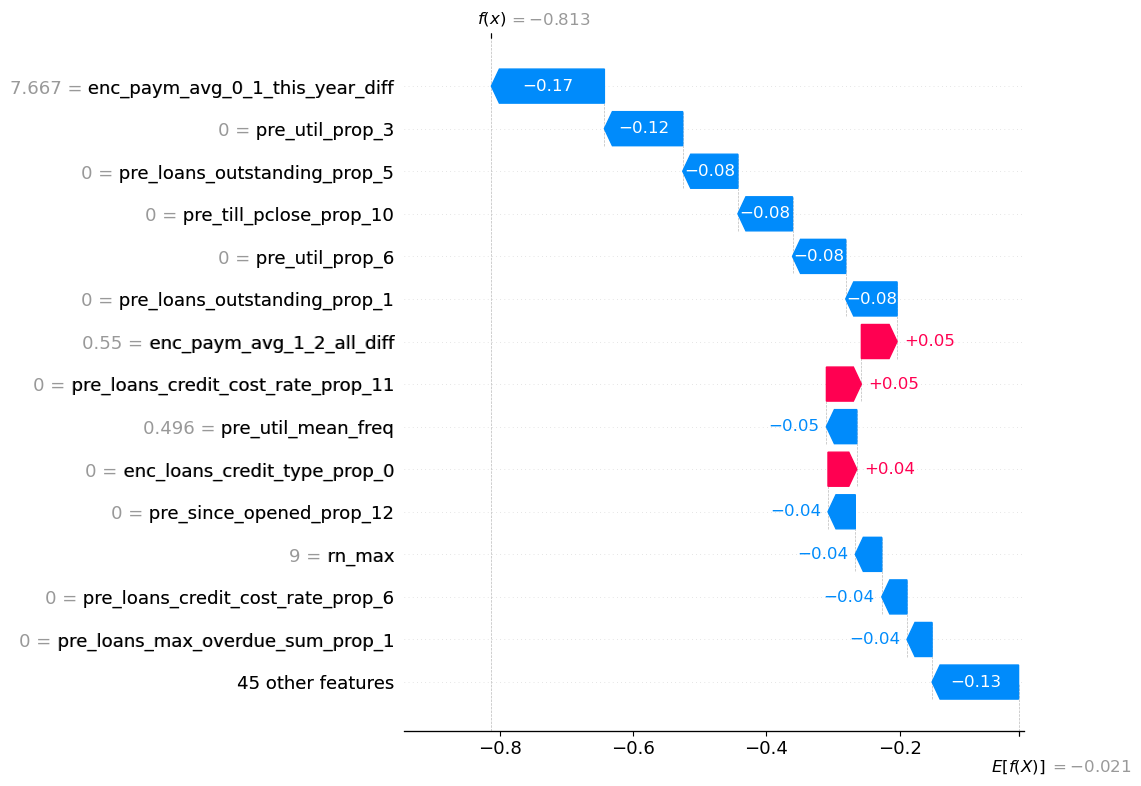

In [23]:
# Создаём объект Explanation для усреднённого (портретного) анализа группы
explanation_median = shap.Explanation(
    values=median_shap_group,            
    base_values=ensemble_base_value,     
    data=median_feature_values,         
    feature_names=X_test.columns 
)

# Строим waterfall plot для 15 топовых признаков
plt.figure(figsize=(8, 6)) 
shap.plots.waterfall(
    explanation_median,                  
    max_display=15
)

Исследуемый признак is_zero_sum_prop_1 отсутствует в первых 15ти позициях рейтинга, но даже лидер группы имеет очень маленькое SHAP значение и не имеет большой разницы со вторым местом. Это свидетельствует о том, что в данной группе вклад признаков в прогнозы модели в целом низок- не только исследуемый признак, но и все остальные признаки выглядят малозначимыми для модели.  
Это повод для целенаправленного feature engineering и пристального анализа данных в этой зоне. Оптимальным планом будет сочетание ручного анализа, создания новых информативных признаков и, при необходимости, применения отдельных моделей или экспертных правил для этой специфической подгруппы.

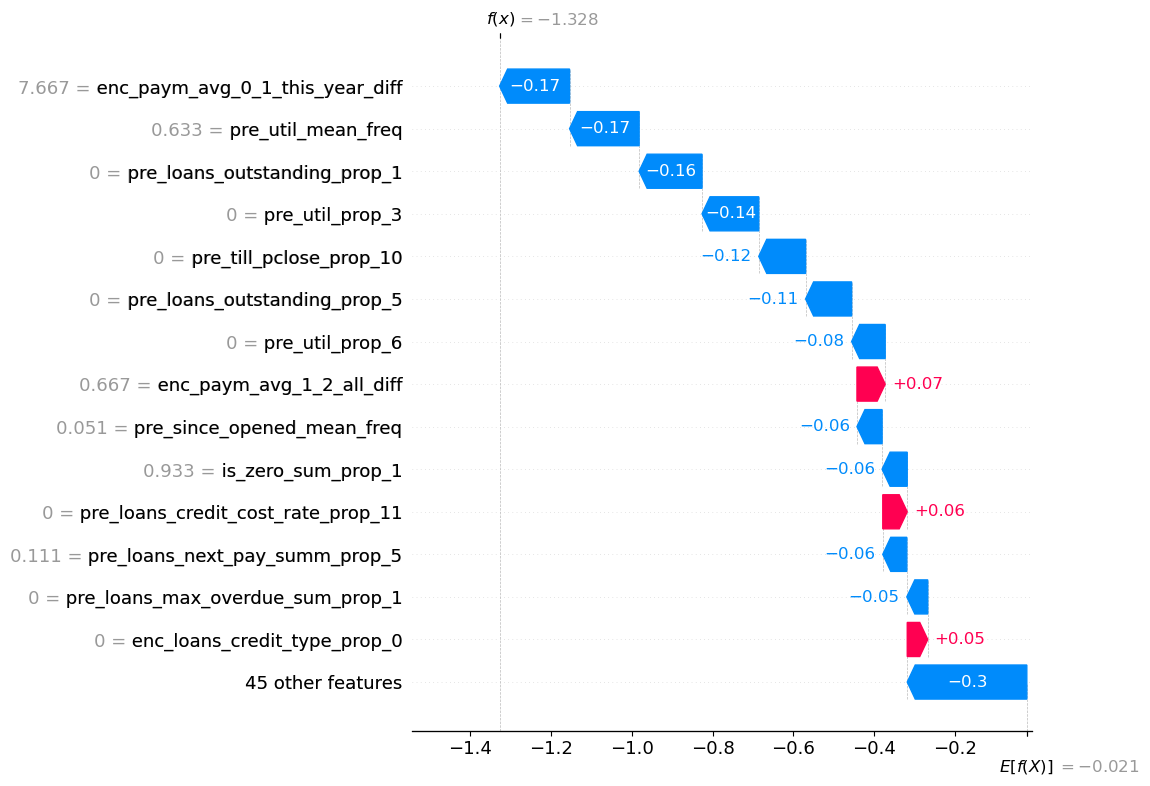

In [24]:
"""
Создадим Waterfall график для  самого типичного представителя группы -
это объект чьи значения признаков ближайшие к медианному вектору группы.
"""

# Считаем L1-расстояние (манхэттенское расстояние) от каждого объекта группы до вектора медиан
dists = np.sum(np.abs(group_features - median_feature_values), axis=1)

# Находим индекс строки внутри группы, ближайшей к медиане
i_typical = np.argmin(dists)

# Находим индекс этого же объекта относительно исходной выборки X_test
idx_typical = idx_group[i_typical]

# Выбираем значения признаков этого объекта
typical_feature_values = group_features[i_typical]

# Выбираем SHAP значения для типичного представителя
shap_typical = avg_shap[idx_typical]

# Создаём объект Explanation для типичного представителя группы
explanation_typical = shap.Explanation(
    values=shap_typical,
    base_values=ensemble_base_value,
    data=typical_feature_values,
    feature_names=X_test.columns
)

plt.figure(figsize=(8, 6))
shap.plots.waterfall(explanation_typical, max_display=15)
plt.show()

Waterfall график для самого типичного представителя группы практически не отличается от графика медианного (портретного) профиля - основной признак is_zero_sum_prop_1 появился на десятом месте рейтинга.  
Но для всех признаков в этой группе SHAP-вклады остаются низкими по модулю и не имееют больших различий, что указывает на отсутствие выраженных драйверов прогноза модели именно в данной зоне признакового пространства.  
Такое совпадение подтверждает однородность группы: модель не может выделить сколько-нибудь значимый фактор для уверенного сдвига прогноза относительно базового значения не только у абстрактного ("портретного") объекта, но и у реально существующего типичного наблюдения.

## enc_paym_avg_0_1_this_year_diff

In [25]:
# Найдем значение признака при котором SHAP value близко к нулю
feature_name = 'enc_paym_avg_0_1_this_year_diff'
# Найдем индекс признака
i = X_test.columns.get_loc(feature_name)
idx_group = np.where(np.abs(avg_shap[:, i]) < 0.05)[0]
idx_group.shape

(62699,)

In [26]:
# Выберем группу объектов с низким SHAP value и оценим их меры среднего
feature_values_group = X_test.iloc[idx_group][feature_name]
group_mean = feature_values_group.mean()
group_median = feature_values_group.median()
print("Среднее группы", group_mean)
print("Медиана группы", group_median)

Среднее группы 6.448354208372542
Медиана группы 6.5


In [27]:
"""
Ориентироваться будем на медианное значение.
Выделим группу объектов находящихся в областях нейтрального
вклада признака в решение моделей ансамбля, с зазором ± 0.01
"""
threshold = 0.01
# Индексы объектов входящих в требуемый диапазон признака
idx_group = np.where(
    (X_test[feature_name] >= group_median - threshold) & 
    (X_test[feature_name] <= group_median + threshold)
)[0]
print("Number of objects in the group", idx_group.shape[0])

Number of objects in the group 7823


In [28]:
"""
Получаем матрицу признаков для группы и 
для каждого признака вычисляем медиану.
"""
group_features = X_test.iloc[idx_group].values
median_feature_values = np.median(group_features, axis=0)
group_features.shape

(7823, 59)

In [29]:
"""
Вычисляем медианные SHAP значения для всех признаков по группе,
avg_shap – массив средневзвешенных SHAP значений 
вычисленный ранее.
"""
median_shap_group = np.median(avg_shap[idx_group], axis=0)

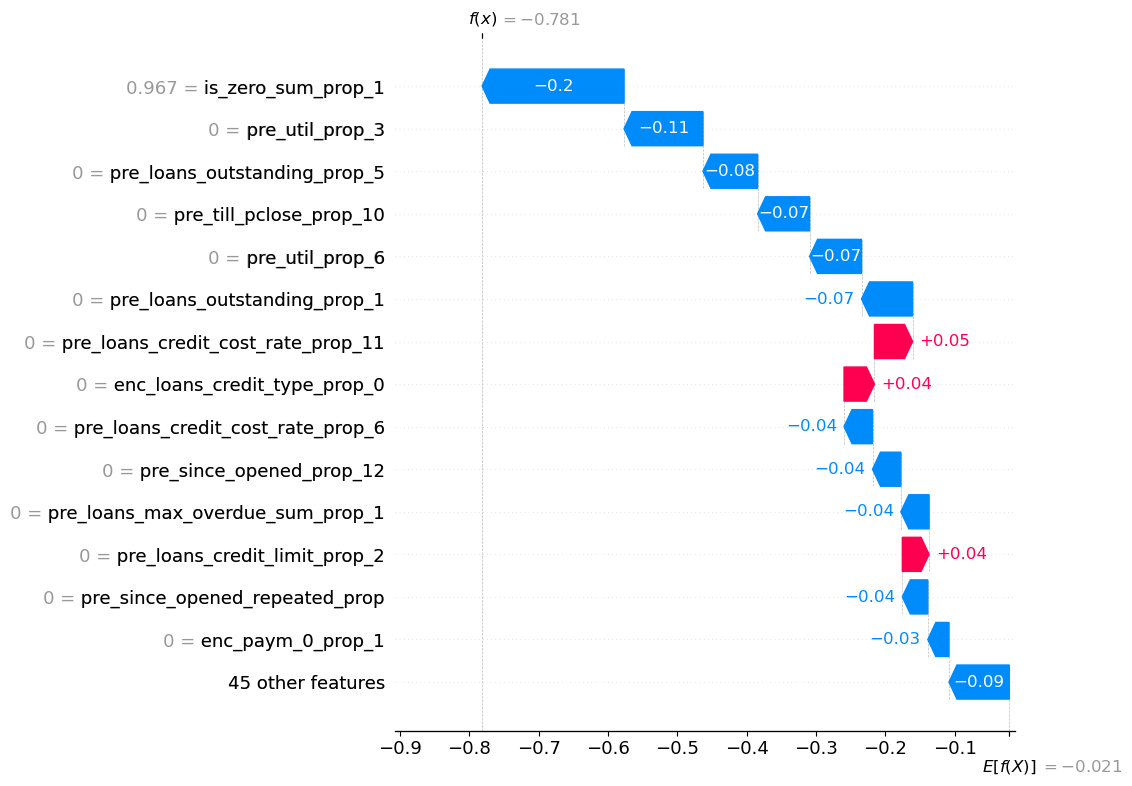

In [30]:
# Создаём объект Explanation для усреднённого (портретного) анализа группы
explanation_median = shap.Explanation(
    values=median_shap_group,            
    base_values=ensemble_base_value,     
    data=median_feature_values,         
    feature_names=X_test.columns 
)

# Строим waterfall plot для 15 топовых признаков
plt.figure(figsize=(8, 6)) 
shap.plots.waterfall(
    explanation_median,                  
    max_display=15
)

Несмотря на то что SHAP значение лидера рейтинга(is_zero_sum_prop_1) по модулю не сильно отличается от значений лидеров на предыдущих двух графиках (is_zero_sum_prop_1) можно сказать что здесь лидер имеет значение в два раза выше чем у второго признака в рейтинге и значительно отличается от SHAP значений остальных признаков. И модели ансамбля при прогнозировании дефолта для представителей этой группы в первую очередь опирается на значение is_zero_sum_prop_1, который является лидирующим рейтингом датасета.

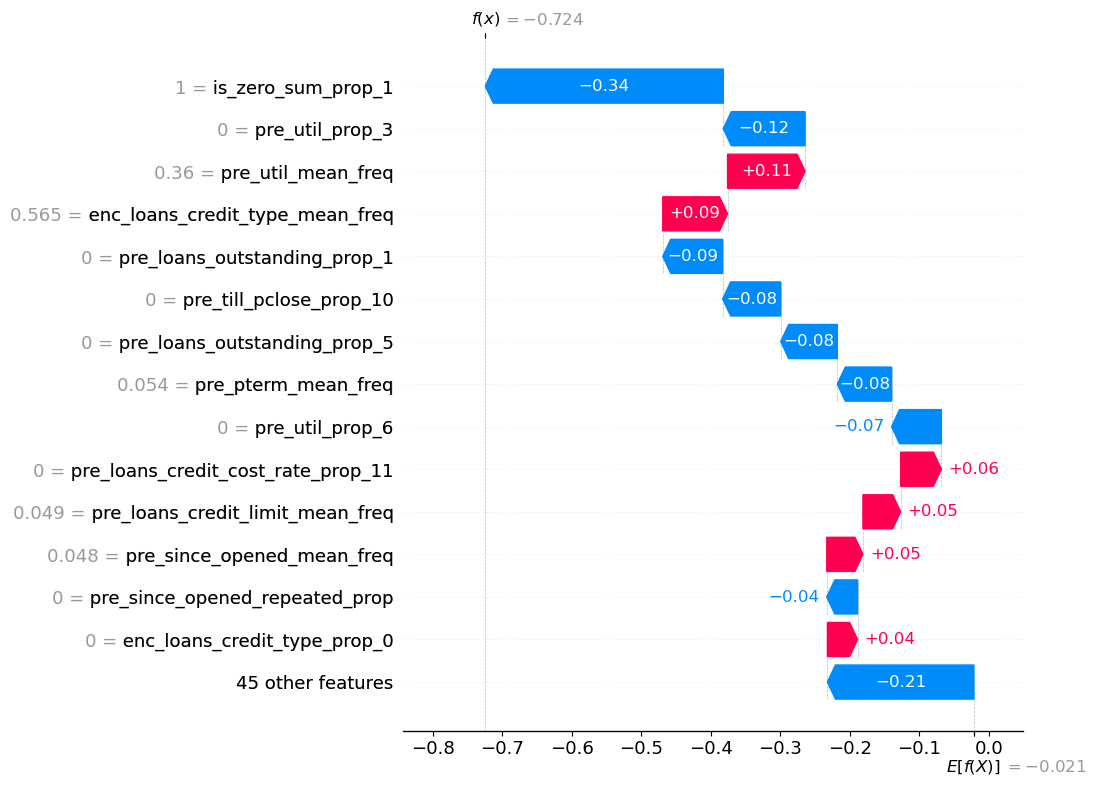

In [31]:
"""
Создадим Waterfall график для  самого типичного представителя группы -
это объект чьи значения признаков ближайшие к медианному вектору группы.
"""

# Считаем L1-расстояние (манхэттенское расстояние) от каждого объекта группы до вектора медиан
dists = np.sum(np.abs(group_features - median_feature_values), axis=1)

# Находим индекс строки внутри группы, ближайшей к медиане
i_typical = np.argmin(dists)

# Находим индекс этого же объекта относительно исходной выборки X_test
idx_typical = idx_group[i_typical]

# Выбираем значения признаков этого объекта
typical_feature_values = group_features[i_typical]

# Выбираем SHAP значения для типичного представителя
shap_typical = avg_shap[idx_typical]

# Создаём объект Explanation для типичного представителя группы
explanation_typical = shap.Explanation(
    values=shap_typical,
    base_values=ensemble_base_value,
    data=typical_feature_values,
    feature_names=X_test.columns
)

plt.figure(figsize=(8, 6))
shap.plots.waterfall(explanation_typical, max_display=15)
plt.show()

Для типичного представителя группы влияние признака is_zero_sum_prop_1 выражено ещё больше, что подтверждает вывод сделанный по графику для портретного представителя группы.

In [32]:
"""
Построим график waterfall для анализа поведения моделей ансамбля в переломной точке 
грпафика dependence признака enc_paym_avg_0_1_this_year_diff.
"""
feature_name = 'enc_paym_avg_0_1_this_year_diff'

# Получаем значения признака для всех объектов выборки
feature_values = X_test[feature_name].values

# Получаем  SHAP значения для этого признака
shap_values = avg_shap[:, X_test.columns.get_loc(feature_name)]

# Сортируем значения признака по возрастанию и соответствующие им SHAP значения
sorted_idx = np.argsort(feature_values)
sorted_feature_values = feature_values[sorted_idx]       
sorted_shap_values = shap_values[sorted_idx]            

"""
Для поиска точки перелома рассчитываем разницы между соседними SHAP value (по модулю)
из массива начиная со второго элемента вычитаем тот же массив без последнего элемента
"""
diff_shap = np.abs(sorted_shap_values[1:] - sorted_shap_values[:-1])

# Определяем индекс максимального значения разницы
max_diff_idx = np.argmax(diff_shap)

"""
Находим значение признака в точке перелома - 
это среднее между двумя соседними значениями признака, где скачок SHAP достигает максимума
"""
breakpoint_value = (sorted_feature_values[max_diff_idx] + sorted_feature_values[max_diff_idx + 1]) / 2

print("Значение признака в точке перелома", breakpoint_value)

Значение признака в точке перелома -0.2290209790209789


In [33]:
# Выделим группу объектов находящихся вблизи точки перлома

threshold = 0.03
# Индексы объектов входящих в требуемый диапазон признака
idx_group = np.where(
    (X_test[feature_name] >= breakpoint_value - threshold) & 
    (X_test[feature_name] <= breakpoint_value + threshold)
)[0]
print("Number of objects in the group", idx_group.shape[0])

Number of objects in the group 106


In [34]:
"""
Получаем матрицу признаков для группы и 
для каждого признака вычисляем медиану.
"""
group_features = X_test.iloc[idx_group].values
median_feature_values = np.median(group_features, axis=0)
group_features.shape

(106, 59)

In [35]:
"""
Вычисляем медианные SHAP значения для всех признаков по группе,
avg_shap – массив средневзвешенных SHAP значений 
вычисленный ранее.
"""
median_shap_group = np.median(avg_shap[idx_group], axis=0)

In [36]:
"""
Вычисляем медианные SHAP значения для всех признаков по группе,
avg_shap – массив средневзвешенных SHAP значений 
вычисленный ранее.
"""
median_shap_group = np.median(avg_shap[idx_group], axis=0)

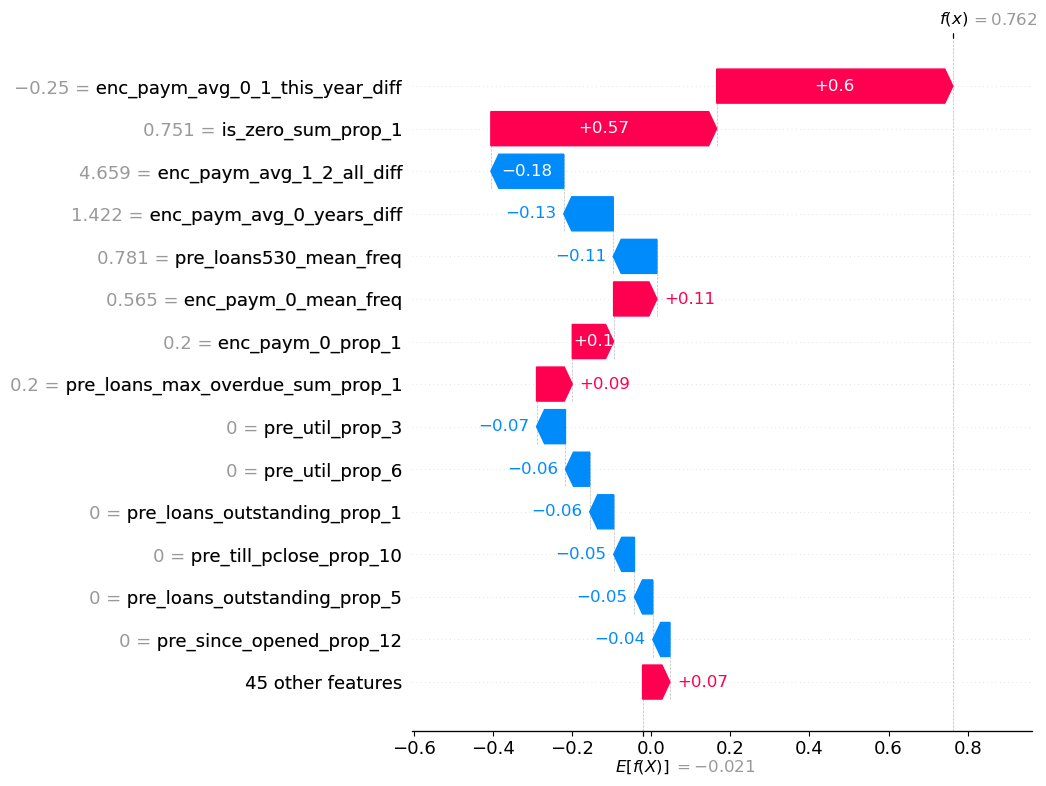

In [37]:
# Создаём объект Explanation для усреднённого (портретного) анализа группы
explanation_median = shap.Explanation(
    values=median_shap_group,            
    base_values=ensemble_base_value,     
    data=median_feature_values,         
    feature_names=X_test.columns 
)

# Строим waterfall plot для 15 топовых признаков
plt.figure(figsize=(8, 6)) 
shap.plots.waterfall(
    explanation_median,                  
    max_display=15
)

Анализируемый признак признак enc_paym_avg_0_1_this_year_diff в области близкой к точке перелома хотя и не сильно, но опережает по влиянию на предсказание второй по значимости признак is_zero_sum_prop_1, и значительно опережает по значимости остальные  переменные. 
Разница между средним количеством позитивных и негативных статусов платежей за последний год показывает совокупное "качество" недавней кредитной дисциплины каждого клиента. Даже незначительное преобладание позитивных статусов над негативными служит сильнейшим индикатором благонадежности, а негативный перекос сигнализирует о высоком риске. 
Этот признак — стратегически важный фактор, определяющий поведение модели и обладающий высокой интерпретируемостью.

# Conclusions

**Общие закономерности и ключевые признаки**  
SHAP-анализ выявил устойчивое ядро значимых признаков, определяющих поведение моделей ансамбля при прогнозировании дефолта.   
Это признаки отражающие аспекты платежной дисциплины клиентов - is_zero_sum_prop_1 - отсутствие просрочек и enc_paym_avg_0_1_this_year_diff (разница между средними частотами позитивных и негативных статусов платежей за год).   

Общий патерны:  
- экстремальные значения приводят к сильным сдвигам прогноза.
- для обоих признаков прослеживается простая взаимосвязь - рост переменной стабильно уменьшает, а снижение наоборот увеличивает вероятность дефолта.

**Согласованность метрик важности**    
По абсолютному SHAP value лидирует is_zero_sum_prop_1(~ 0.28/0.24), по классической feature importance enc_paym_avg_0_1_this_year_diff(~ 12.7/9.5), разница в обоих случаях небольшая. Ориентироваться следует на SHAP - она лучше фиксирует пороговые и контекстные эффекты.  
Общая устойчивость этих метрик подтверждает надёжность модели и информативность данных.  
Значения метрик сильно превышают показатели остальных признаков.  

**Зависимости и взаимодействия**  
is_zero_sum_prop_1  
Монотонное снижение SHAP value при росте значений признака; нейтральная зона около 0.9, где вклад минимален.  
Выраженное взаимодействие с pre_util_mean_freq, усиливающее или ослабляющее эффект в зависимости от типичности кредитной нагрузки.

enc_paym_avg_0_1_this_year_diff   
Нелинейная зависимость с пороговым скачком около 0, все отрицательные значения признака дают одинаковое влияние на модель и говорят о риске дефолта.  
Нейтральная область около 5. 
Взаимодействие с pre_till_pclose_prop_10 (доля в кредитах клиента некоего интервала признака "Плановое количество дней с даты сбора данных до даты закрытия кредита"), меняющееся по знаку до и после нейтральной зоны.  

**Поведение в специальных зонах**  
В зоне нейтрального влияния признака enc_paym_avg_0_1_this_year_diff модель опирается на is_zero_sum_prop_1 подтверждая его глобальную значимость.  
В переломной точке enc_paym_avg_0_1_this_year_diff этот признак по влиянию слегка опережает is_zero_sum_prop_1, доминируя над остальными. Даже малый позитивный баланс статусов резко снижает риск.
А в зоне нейтрального влияния самого важного признака is_zero_sum_prop_1 ни один из признаков не берёт на себя выраженную роль лидера - вклад всех низок. Это указывает на однородность группы и необходимость уделения ей особого внимания.   
Особенно это актуально тем что к этой группе можно отнести от 8 до 10 процентов клиентов. 

**Рекомендации и выводы**  
В целом модели ансамбля показали хорошую интерпретируемость, устойчивое ядро признаков и чёткие пороговые эффекты для разделения классов.
Фокусироваться следует на топ-признаках для скоринга — регулярность платежей и баланс статусов как ключевые индикаторы.  
Для группы клиентов из зоны нейтрального влияния следует найти дополнительные признаки либо обучить модель другого класса или собрать стек моделей. Можно также ввести для них ручной отбор хотя для этого группа слишком многочисленна. 
Дополнительными признаками могут стать более детализированные признаки разницы статусов платежей, например за последние пол года или несколько месяцев.